# Computing the region of parameter space for the big planet using fraction of area

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

#### Reading in binary and single lens magnification maps

In [2]:
s1s = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
q1s = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3]

binary_directory = '../Unity/Simulations/Binary_Collection/'
single_directory = '../Unity/Simulations/Single_Collection/'

In [27]:
s1_ind = 3
q1_ind = -1

single_file = f'{single_directory}single_{q1s[q1_ind]:.0e}_{s1s[s1_ind]:.2e}.pkl'
binary_file = f'{binary_directory}binary_{q1s[q1_ind]:.0e}_{s1s[s1_ind]:.2e}.pkl'

print(f'Loading single lens simulation from {single_file}...')
print(f'Loading binary lens simulation from {binary_file}...')
print(f'Using s1 = {s1s[s1_ind]:.2f} and q1 = {q1s[q1_ind]:.0e}')

single_sim = IRSC.caustic_reader(single_file)
binary_sim = IRSC.caustic_reader(binary_file)

Loading single lens simulation from ../Unity/Simulations/Single_Collection/single_1e-03_5.00e-01.pkl...
Loading binary lens simulation from ../Unity/Simulations/Binary_Collection/binary_1e-03_5.00e-01.pkl...
Using s1 = 0.50 and q1 = 1e-03


In [28]:
import sys
from types import ModuleType, FunctionType

# A helper to avoid double-counting objects
def get_size(obj, seen=None):
    """Recursively finds the size of objects in bytes."""
    size = sys.getsizeof(obj)
    # if seen is None:
    #     seen = set()
    # obj_id = id(obj)
    # if obj_id in seen:
    #     return 0
    # seen.add(obj_id)

    if isinstance(obj, dict):
        size += sum([get_size(v, seen) + get_size(k, seen) for k, v in obj.items()])
    elif isinstance(obj, np.ndarray):
        size += obj.nbytes
    # elif hasattr(obj, "__dict__"):
    #     size += get_size(vars(obj), seen)
    # elif hasattr(obj, "__iter__") and not isinstance(obj, (str, bytes, bytearray)):
    #     size += sum([get_size(i, seen) for i in obj])
    return size


def class_size(obj):
    """Iterates through all attributes of a class instance and reports sizes."""
    total = sys.getsizeof(obj)
    details = {}
    
    for attr_name in dir(obj):
        # Skip dunder methods and functions
        if attr_name.startswith("__") and attr_name.endswith("__"):
            continue

        try:
            attr = getattr(obj, attr_name)
        except AttributeError as e:
            print(attr_name)
            continue

        # if isinstance(attr, (ModuleType, FunctionType)):
        #     continue

        size = get_size(attr)
        details[attr_name] = size
        total += size
    
    return total, details

total_size, size_details = class_size(binary_sim)
print(f"Total size of binary_sim: {total_size / (1024 ** 2):.5f} MB")
print("Size breakdown by attribute:")
for attr, size in size_details.items():
    print(f"  {attr}: {size / (1024 ** 2):.5f} MB")

show_lenses
zoom
Total size of binary_sim: 128.28840 MB
Size breakdown by attribute:
  L: 0.00003 MB
  X_pix: 30.51770 MB
  Y_pix: 30.51770 MB
  _ang_width: 0.00003 MB
  _lens_att_list: 0.00011 MB
  _pixels: 0.00003 MB
  _source_att: 0.00002 MB
  _worker_calc_magnification_parallel: 0.00006 MB
  analyze: 0.00006 MB
  ang_res: 0.00003 MB
  ang_width: 0.00003 MB
  ang_width_thickness_calculator: 0.00014 MB
  annulus_param_checker: 0.00014 MB
  calc_CM: 0.00006 MB
  calc_a_mags: 0.00006 MB
  calc_image: 0.00006 MB
  calc_mags: 0.00015 MB
  calc_mm_caustics: 0.00006 MB
  calc_source: 0.00006 MB
  calc_source_pixels: 0.00006 MB
  calc_uniques: 0.00015 MB
  calculate: 0.00006 MB
  caustic_cusps: 0.00002 MB
  circle: 0.00006 MB
  cm_offset: 0.00014 MB
  convolve: 0.00006 MB
  cpus: 0.00003 MB
  create_annulus: 0.00015 MB
  disable_tqdm: 0.00003 MB
  dr: 0.00003 MB
  dtheta: 0.00002 MB
  file_save: 0.00002 MB
  import_file: 0.00006 MB
  init_grid: 0.00006 MB
  lens_CM: 0.00014 MB
  lens_att: 0

In [29]:
pixels = single_sim.pixels
ang_res = single_sim.ang_res
ang_width = single_sim.ang_width

#### Plotting single lens magnification map

{'pixels': 2000, 'ang_width': np.float64(0.006001998001998), 'thickness': np.float64(0.0046684588366688), 'y_plus': np.float64(1.0023369537281122), 'y_minus': np.float64(-0.9976684948914432), 'lens_att': [[0, 0, 1]], 'num_theta': 203537, 'num_r': 814148, 'ang_res': np.float64(3.0025002511245623e-06), 'pixel_density': np.float64(333055.7589880161), 'dr': np.float64(5.7341718837860974e-09), 'dtheta': 0.0017687201835538502, 'num_rays': 165709241476}
Plotting magnification map: 0.051 seconds


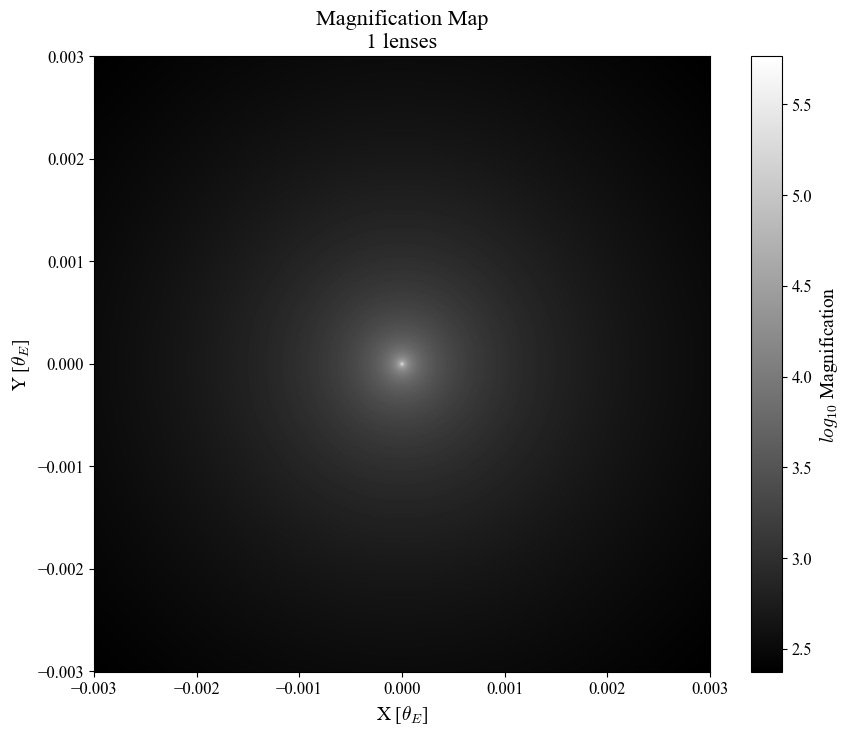

In [30]:
print(single_sim.param_dict)
single_sim.plot()

plt.show()

#### Plotting binary lens magnification map

{'pixels': 2000, 'ang_width': np.float64(0.006001998001998), 'thickness': np.float64(0.0046684588366688), 'y_plus': np.float64(1.0023369537281122), 'y_minus': np.float64(-0.9976684948914432), 'lens_att': [[-0.0003996003996003997, 0.0, 1.0], [0.4996003996003996, 0.0, 0.001]], 'num_theta': 203537, 'num_r': 814148, 'ang_res': np.float64(3.0025002511245623e-06), 'pixel_density': np.float64(333055.7589880161), 'dr': np.float64(5.7341718837860974e-09), 'dtheta': 0.0017687201835538502, 'num_rays': 165709241476}
Plotting magnification map: 0.045 seconds


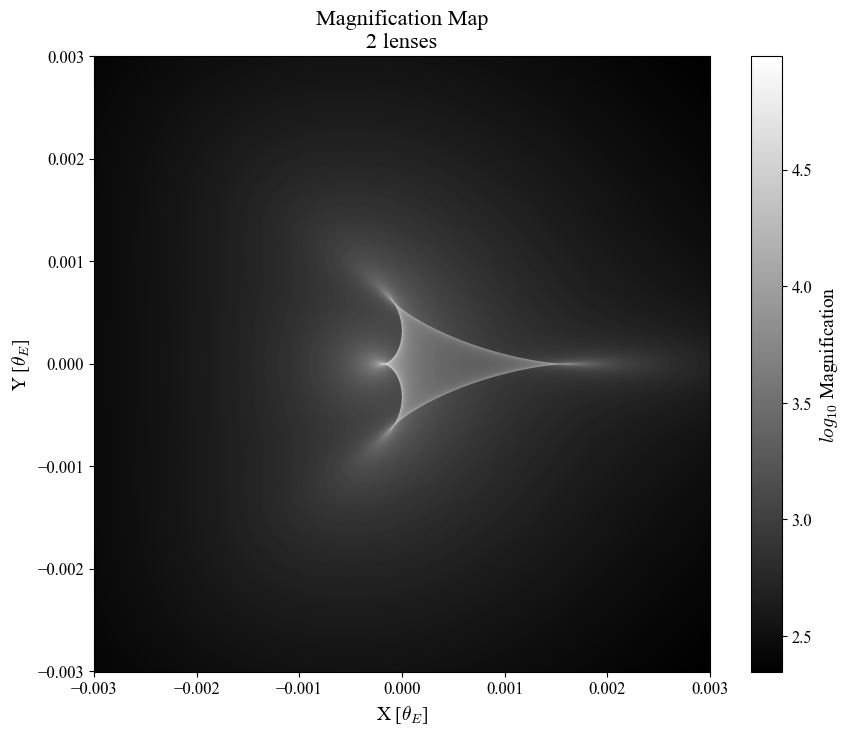

In [31]:
print(binary_sim.param_dict)
binary_sim.plot()

plt.show()

#### Defining source profile

In [32]:
radius = 1e-3
LD = 0.5

source_profile_size = int(2 * radius / ang_res)
print(source_profile_size)

666


100%|██████████| 666/666 [00:00<00:00, 1236.29it/s]


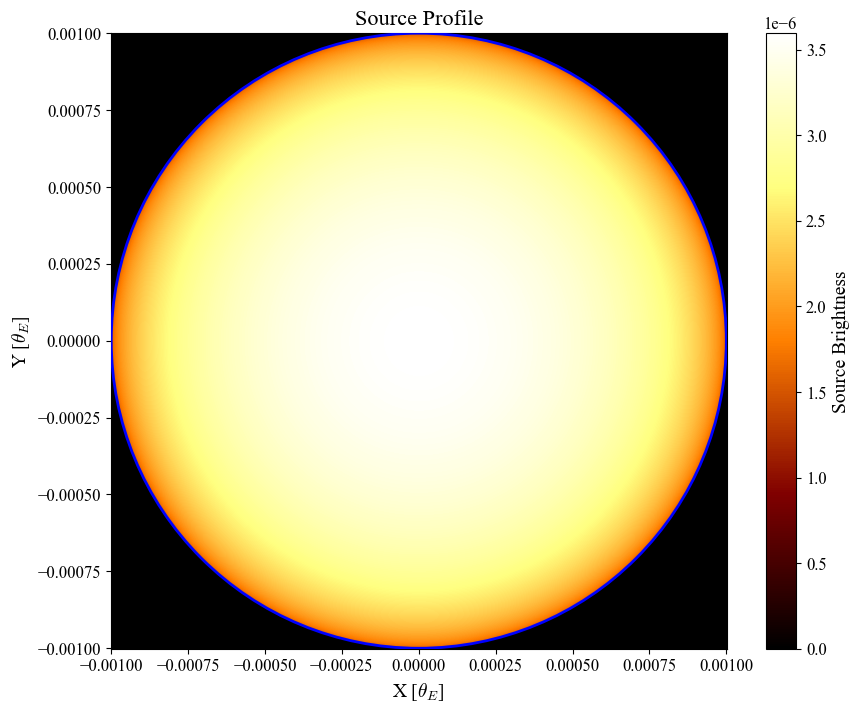

In [33]:
source_profile = IRSF.IRSFunctions.source_profile(ang_res=ang_res, rad=radius, profile_type='LD', LD=LD, supersample=10)

if source_profile_size < 10000:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot()

    img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius - ang_res / 2, radius + ang_res / 2, -radius - ang_res / 2, radius + ang_res / 2])
    plt.colorbar(img, ax=ax, label='Source Brightness')

    source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
    ax.add_patch(source_patch)

    ax.set_xlabel('X [$\\theta_E$]')
    ax.set_ylabel('Y [$\\theta_E$]')
    ax.set_title('Source Profile')

    ax.set_aspect('equal')

    plt.show()

else:
    print('Source profile is too large to display.')

#### Convolving single lens and binary lens magnification maps with source profile

In [10]:
single_brightnesses = single_sim.convolve(source_profile)
binary_brightnesses = binary_sim.convolve(source_profile)

Convolving source profile with magnification map: 0.225 seconds
Convolving source profile with magnification map: 0.192 seconds


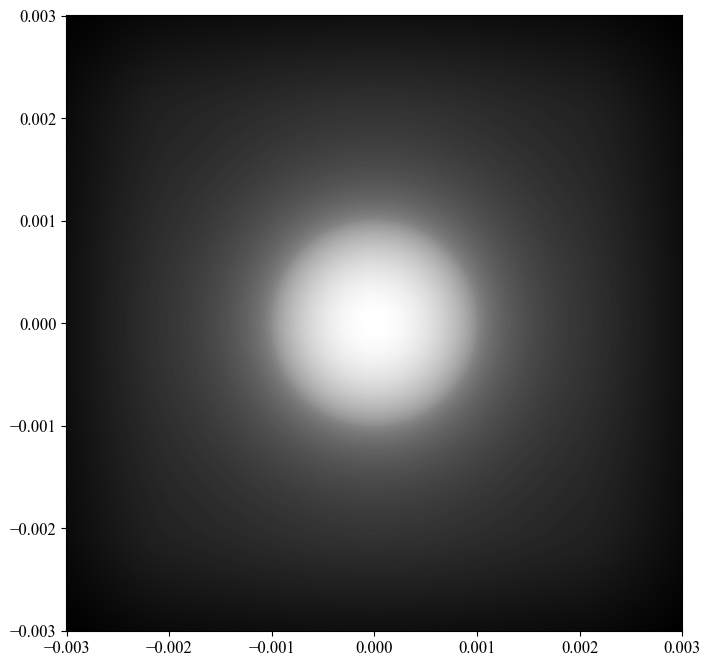

In [11]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(single_brightnesses, cmap='gray', extent=[-ang_width/2 - ang_res/2, ang_width / 2 + ang_res/2, -ang_width / 2 - ang_res/2, ang_width / 2 + ang_res/2])

plt.show()

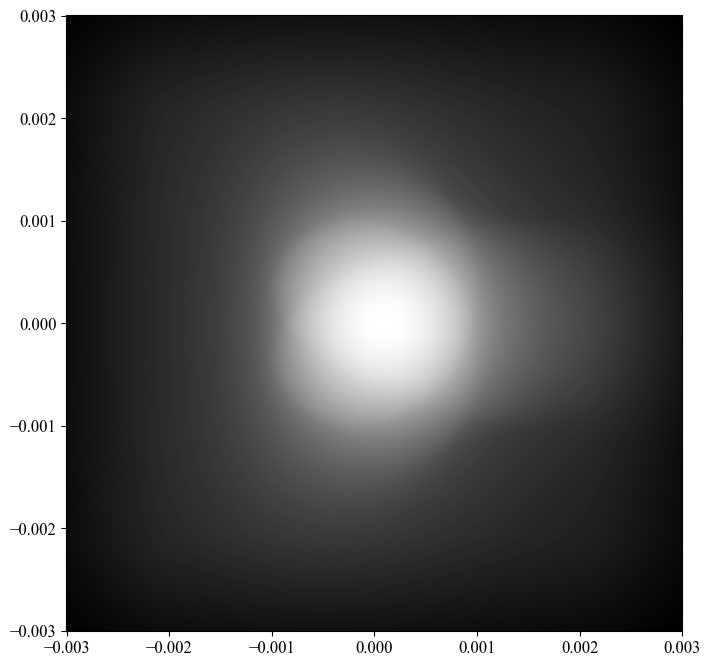

In [12]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(binary_brightnesses, cmap='gray', extent=[-ang_width/2 - ang_res/2, ang_width / 2 + ang_res/2, -ang_width / 2 - ang_res/2, ang_width / 2 + ang_res/2])

plt.show()

#### Computing fractional deviation between binary and single lens convolved brightnesses

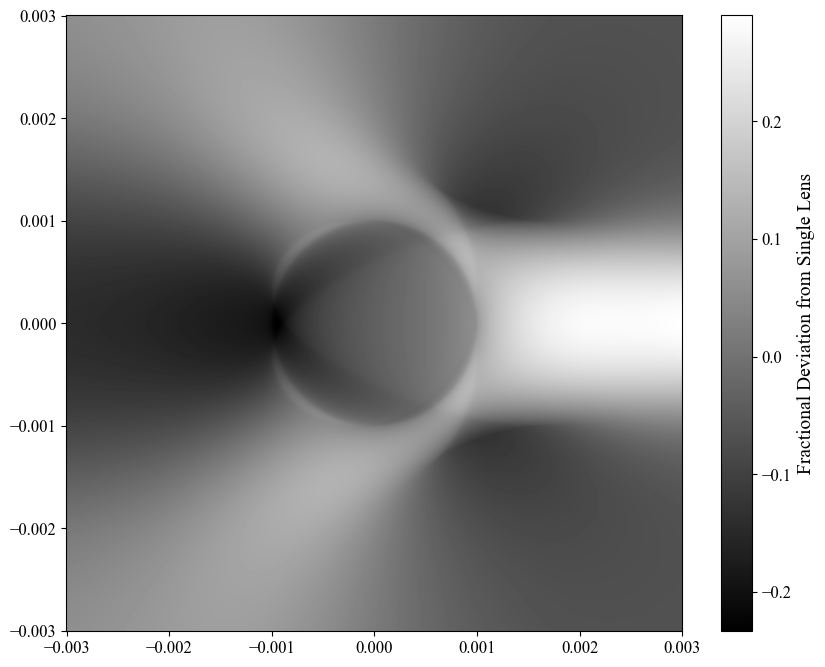

In [13]:
fractional_deviation = (binary_brightnesses - single_brightnesses) / single_brightnesses

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(fractional_deviation, cmap='gray', extent=[-ang_width/2 - ang_res/2, ang_width / 2 + ang_res/2, -ang_width / 2 - ang_res/2, ang_width / 2 + ang_res/2])
plt.colorbar(img, ax=ax, label='Fractional Deviation from Single Lens')

plt.show()

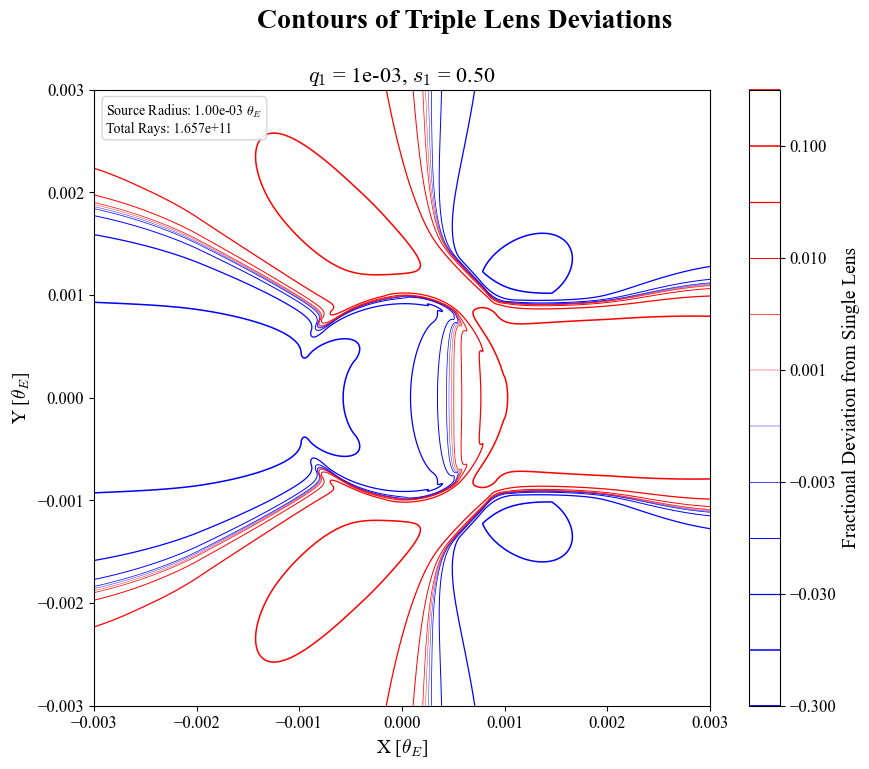

In [14]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Contours of Triple Lens Deviations')

img = plt.contour(single_sim.X_pix, single_sim.Y_pix, fractional_deviation,
                  levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                  colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                  linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                  zorder=0
)

bar = plt.colorbar(img)
bar.set_label('Fractional Deviation from Single Lens')

ax.set_title(f'$q_1$ = {q1s[q1_ind]:.0e}, $s_1$ = {s1s[s1_ind]:.2f}')
ax.set_aspect('equal')
ax.set_xlim(-ang_width/2, ang_width/2)
ax.set_ylim(-ang_width/2, ang_width/2)

props = dict(boxstyle='round', facecolor='white', edgecolor='lightgray', alpha=0.9)
ax.text(0.02, 0.98, f'Source Radius: {radius:.2e} $\\theta_E$\nTotal Rays: {(single_sim.num_rays):.3e}', va='top', zorder=10, bbox=props, transform=ax.transAxes, color='black')

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')

# fig.savefig('Contours_Accurate.png', dpi=500)

plt.show()

#### Finding ratio of area

In [14]:
x = np.logspace(-7, 0, 8)

for threshold in x:
    print(f'Threshold: {threshold}')
    area = np.sum(np.abs(fractional_deviation) < threshold) / pixels**2
    print(area)

Threshold: 1e-07
2.5e-07
Threshold: 1e-06
6e-06
Threshold: 1e-05
6.9e-05
Threshold: 0.0001
0.000719
Threshold: 0.001
0.00700975
Threshold: 0.01
0.0710655
Threshold: 0.1
0.8073035
Threshold: 1.0
1.0


#### Repeating for every binary lens configuration